1. Loading Telecom Customer Data...

Dataset Overview:


,CustomerID,Age,MonthlyCharge,Tenure_Months,SupportTickets,Churn
0,1,41,90.447639,42,3,0
1,2,36,63.227503,32,1,0
2,3,66,58.372370,55,0,0
3,4,62,62.281583,24,0,0
4,5,40,112.792158,17,1,0



2. Exploratory Data Analysis (EDA)...


/tmp/ipykernel_3657/2076472527.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharge', data=df, palette=['#4CAF50', '#F44336'])


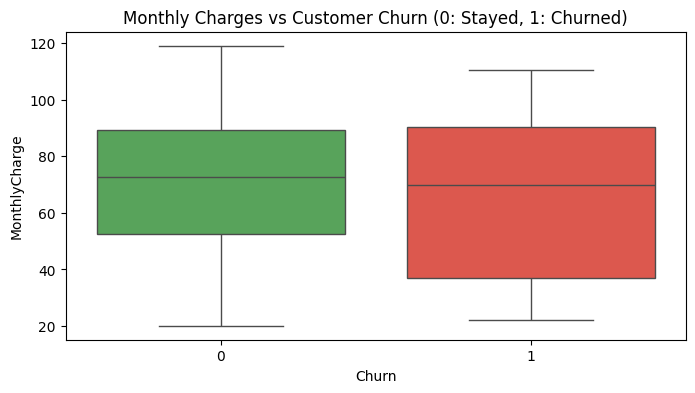

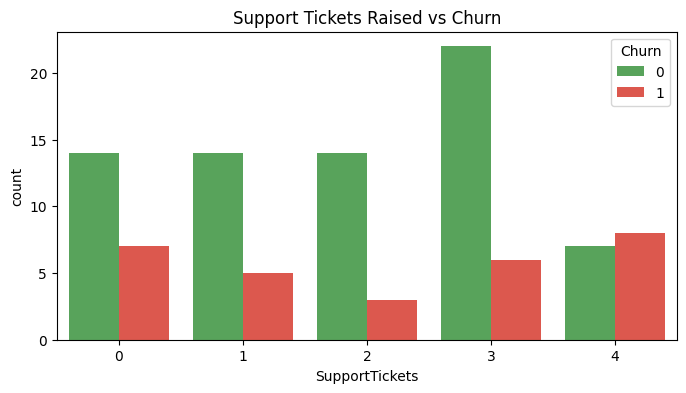

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("1. Loading Telecom Customer Data...")
# Generating a sample dataset
data = {
    'CustomerID': range(1, 101),
    'Age': np.random.randint(18, 70, 100),
    'MonthlyCharge': np.random.uniform(20, 120, 100),
    'Tenure_Months': np.random.randint(1, 72, 100),
    'SupportTickets': np.random.randint(0, 5, 100),
    'Churn': np.random.choice([0, 1], size=100, p=[0.7, 0.3]) # 0 = Stayed, 1 = Left
}
df = pd.DataFrame(data)

print("\nDataset Overview:")
display(df.head())

print("\n2. Exploratory Data Analysis (EDA)...")
# Plotting Churn vs Monthly Charges
plt.figure(figsize=(8, 4))
sns.boxplot(x='Churn', y='MonthlyCharge', data=df, palette=['#4CAF50', '#F44336'])
plt.title('Monthly Charges vs Customer Churn (0: Stayed, 1: Churned)')
plt.show()

# Plotting Support Tickets impact on Churn
plt.figure(figsize=(8, 4))
sns.countplot(x='SupportTickets', hue='Churn', data=df, palette=['#4CAF50', '#F44336'])
plt.title('Support Tickets Raised vs Churn')
plt.show()

In [2]:
print("3. Preparing Data for Machine Learning...")
# Features (X) and Target (y)
X = df[['Age', 'MonthlyCharge', 'Tenure_Months', 'SupportTickets']]
y = df['Churn']

# 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("4. Training Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("5. Evaluating the Model...")
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"✅ Accuracy Score: {accuracy * 100:.2f}%")
print(f"✅ ROC-AUC Score: {roc_auc:.2f}\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance (Konsa factor sabse zyada effect karta hai)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n🔍 Key Factors driving Customer Churn:")
print(importances)

3. Preparing Data for Machine Learning...
4. Training Random Forest Classifier...
5. Evaluating the Model...
✅ Accuracy Score: 60.00%
✅ ROC-AUC Score: 0.50

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.79      0.73        14
           1       0.25      0.17      0.20         6

    accuracy                           0.60        20
   macro avg       0.47      0.48      0.47        20
weighted avg       0.56      0.60      0.57        20


🔍 Key Factors driving Customer Churn:
MonthlyCharge     0.312197
Tenure_Months     0.287968
Age               0.271580
SupportTickets    0.128254
dtype: float64


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

print("1. Downloading REAL Telecom Dataset from IBM/Kaggle...")
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
real_df = pd.read_csv(url)

print(f"Dataset Loaded! Total Customers: {len(real_df)}")

print("\n2. Cleaning and Preprocessing Data...")
# TotalCharges column mein kuch khali spaces hain, unhe theek karna
real_df['TotalCharges'] = pd.to_numeric(real_df['TotalCharges'], errors='coerce')
real_df.dropna(inplace=True) # Khali rows hatana
real_df.drop('customerID', axis=1, inplace=True) # ID ka prediction mein kaam nahi

# Text data (Yes/No, Internet type) ko Numbers (0/1) mein convert karna
le = LabelEncoder()
for col in real_df.select_dtypes(include=['object']).columns:
    real_df[col] = le.fit_transform(real_df[col])

print("\n3. Training Model on Real Data...")
X = real_df.drop('Churn', axis=1)
y = real_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\n4. Final Model Evaluation...")
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"🔥 FINAL ACCURACY: {accuracy * 100:.2f}%")
print(f"🔥 FINAL ROC-AUC: {roc_auc:.2f}\n")

print("Detailed Report:")
print(classification_report(y_test, y_pred))

# Check real feature importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)
print("\nTop 5 Real Reasons for Customer Churn:")
print(importances)

1. Downloading REAL Telecom Dataset from IBM/Kaggle...
Dataset Loaded! Total Customers: 7043

2. Cleaning and Preprocessing Data...

3. Training Model on Real Data...

4. Final Model Evaluation...
🔥 FINAL ACCURACY: 79.25%
🔥 FINAL ROC-AUC: 0.81

Detailed Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Top 5 Real Reasons for Customer Churn:
TotalCharges      0.184953
MonthlyCharges    0.178014
tenure            0.154510
Contract          0.080585
PaymentMethod     0.052031
dtype: float64
